In [33]:
import os
import h5py
import numpy as np
from scipy.integrate import solve_ivp
from scipy.stats.qmc import Halton
from time import time
import matplotlib.pyplot as plt
from joblib import Parallel, delayed  # For parallel execution
from scipy.ndimage import gaussian_filter1d
from scipy.stats import skewnorm
from scipy.stats import truncnorm
import umap.umap_ as umap
from scipy.interpolate import interp1d

In [34]:
import torch

In [35]:
# File paths
old_file_path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/Old equations/datasets/trials_many_alldata_v3.h5"
new_file_path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/trials_many_alldata_new_eqution_halton_noisy.h5"
exprimental_data_nondimensional_path_h5 = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/experimental_data_nondimensional_2.h5"

Constants

In [36]:
halton_sampler = Halton(d=7, scramble=True, seed=42)
halton_sequence = halton_sampler.random(n=300000).flatten()
halton_sequence = np.reshape(halton_sequence, (300000, 7))

In [37]:
ts_range = [10., 60.] # Characteristic time scale (s)
ts_halton = ts_range[0] + (ts_range[1] - ts_range[0]) * halton_sequence[:,0]

h_range = [2e-6, 8e-6] # Characteristic height (m)
h_threshold = 0.5e-6
h_0_values = h_range[0] + (h_range[1] - h_range[0]) * halton_sequence[:,1]

J_e_range = [0., 40e-6] # Characteristic evaporation rate (m/minute)
J_e_primes = J_e_range[0] + (J_e_range[1] - J_e_range[0]) * halton_sequence[:,2]
J_e_primes = J_e_primes / 60. # Convert to m/s
J_e_values = J_e_primes * ts_halton / h_0_values

f_0_range = [0.0008, 0.002] # Characteristic fluorescence (%)
f_cr = 5.3e-3 # Critical fluorescence (%)
f_0_primes = f_0_range[0] + (f_0_range[1] - f_0_range[0]) * halton_sequence[:,3]
f_0_values = f_0_primes / f_cr

b_1_range = [-0.2, 2.] # (s^-1)
b_1_primes = b_1_range[0] + (b_1_range[1] - b_1_range[0]) * halton_sequence[:,4]
b_1_values = b_1_primes * ts_halton

b_2_range = [0., 2.] # (s^-1)
b_2_primes = b_2_range[0] + (b_2_range[1] - b_2_range[0]) * halton_sequence[:,5]
b_2_values = b_2_primes * ts_halton

# Rescale to be in the range 0.5 to 1.0
h_e_range = [0.5e-6, 1e-6] # Characteristic height (m)
h_e_halton = h_e_range[0] + (h_e_range[1] - h_e_range[0]) * halton_sequence[:,6]
h_e_values = np.array(h_e_halton) / np.array(h_0_values)


In [38]:
rho = 1e0 # Water density (Kg/L)  [Why Kg/L and not g/L or Kg/m^3?]
P_c_hat = 12.1e-6 # (m/s)
Vw = 18e-6 # Molar volume of water (m^3/Mol)
c_0 = 300 # Serum Osmolarity (Mol/m^3)
sigma_0 = 0.045 # N/m
mu = 1.3e-3 # Pa.s
f_cr = 0.002 # Critical fluorescence (%)

# Solute parameters
Mw_FL = 376e-3 # molecular weight of Na_2FL, (Kg/mol)

# Naperian extinction coefficient
eps_f = 1.75e7 # m^-1 M^-1
# transmittance parameter
fcr2 = rho * f_cr / Mw_FL


In [39]:
phi_values = eps_f*fcr2*h_0_values
Pc_values = P_c_hat*Vw*c_0/(h_0_values/ts_halton)

In [40]:
# Function to calculate I
def calculate_I(h, f, phi, I_0=1.0):
    return I_0 * (1 - np.exp(-phi * h * f)) / (1 + f ** 2)


In [128]:
# Differential system (P_c is a constant and does not need to be passed as an argument)
def differential_system(t, y, J_e, b_1, b_2, h_e, P_c):
    h, c = y
    g_t = b_1 * np.exp(-b_2 * t)
    dh_dt = -g_t * h - J_e * (1 - (h_e / h) ** 3) + P_c * (c - 1)
    dc_dt = -g_t * c - dh_dt * (c / h)
    return [dh_dt, dc_dt]

def generate_and_store_dataset():  
    valid_h, valid_c, valid_f, valid_I, valid_p, rejected_index = [], [], [], [], [], []
    time_grid = np.linspace(0, 1, 601)  # Time grid for integration
    fixed_length = len(time_grid) 
    
    h_e = 0        # When we are assuming constant evaporation 
        
    def solve_single_instance(i):
        J_e_prime, b_1_prime, b_2_prime, f_0, Pc, phi, h0, ts = (J_e_primes[i], b_1_primes[i], b_2_primes[i],
                                            f_0_values[i], Pc_values[i], phi_values[i], h_0_values[i], ts_halton[i])
        J_e = J_e_prime * ts / h0
        b_1 = b_1_prime * ts
        b_2 = b_2_prime * ts
        y0 = [1.0, 1.0]
        sol = solve_ivp(
            differential_system,
            [0., 1.],
            y0,
            t_eval=time_grid,
            args=(J_e, b_1, b_2, h_e, Pc),
            method='LSODA',
        )
        
        if np.max(sol.y[0]) > 1.1 or sol.y[0][-1] > 1.5 * np.min(sol.y[0]):
        # if np.max(sol.y[0]) > 1.1 or sol.y[0][-1] > 1.2 * np.min(sol.y[0]) or np.max(sol.y[1]) > 25:
            rejected_index.append(i)  # Store the index of rejected cases
            return None  # Skip rejected cases
        elif sol.y[0].shape[0] < fixed_length:
            rejected_index.append(i)  # Store the index of rejected cases
            return None
        else:
            h = sol.y[0]
            c = sol.y[1]
            f = f_0 * c
            I0 = 1 / calculate_I(h[0], f[0], phi, I_0=1.0)
            I = calculate_I(h, f, phi, I_0=I0)
            if np.any(np.diff(I) > 0):
                rejected_index.append(i)
                return None
            elif np.min(np.diff(I)) < 0.1 * np.max(np.diff(I)):
                def clip_and_interpolate(I, target_length=601, multiplier=0.001, window_size=20, extension=0.02):
                    """
                    Clips the time series I when the rate of change becomes small and interpolates to a fixed length.
                    If the clipped segment is too short, skips clipping and uses the full series.

                    Parameters:
                        I (array-like): The input intensity array.
                        target_length (int): Number of points to interpolate to.
                        multiplier (float): Fraction of max rate of change to set as threshold.
                        window_size (int): Number of consecutive points to confirm low rate of change.
                        extension (float): Fraction of t_crit to extend the clip boundary.

                    Returns:
                        I_interp (np.ndarray): Interpolated array of length `target_length`.
                        clip_point (int): Index at which the series was clipped (or len(I) if not clipped).
                    """
                    I = np.array(I)
                    t = np.arange(len(I))
                    
                    # Compute the rate of change (first derivative)
                    rate_of_change = np.abs(np.gradient(I))
                    
                    # Compute adaptive threshold
                    threshold = multiplier * np.max(rate_of_change)
                    
                    # Find t_crit: where curve starts to flatline
                    t_crit = len(I)
                    for i in range(len(rate_of_change) - window_size):
                        if np.all(rate_of_change[i:i+window_size] < threshold):
                            t_crit = i
                            break
                    
                    # Apply extension to retain a bit of the flatline
                    cutoff_index = min(int(t_crit * (1 + extension)), len(I))
                    
                    # cutoff_index = t_crit
                    
                    # Clip
                    t_clipped = t[:cutoff_index]
                    I_clipped = I[:cutoff_index]
                    
                    # Fallback: if too short, use full series
                    if len(t_clipped) < 2 or cutoff_index >= 551:
                        I_clipped = I
                        t_clipped = t
                        cutoff_index = len(I)
                    
                    # Interpolate
                    interp_func = interp1d(t_clipped, I_clipped, kind='linear')
                    t_interp = np.linspace(t_clipped[0], t_clipped[-1], target_length)
                    I_interp = interp_func(t_interp)
                    
                    return I_interp, cutoff_index, t_clipped

                I_interp, cutoff_index, t_clipped = clip_and_interpolate(I, target_length=fixed_length, multiplier=0.05, window_size=20, extension=0.02)
                ts_new = t_clipped[-1]  # Use the last time point of the clipped series
                h_clipped = h[:cutoff_index]
                c_clipped = c[:cutoff_index]
                t_clipped = time_grid[:cutoff_index]

                # Interpolate to length 601
                interp_func_h = interp1d(t_clipped, h_clipped, kind='linear')
                interp_func_c = interp1d(t_clipped, c_clipped, kind='linear')
                t_interp = np.linspace(t_clipped[0], t_clipped[-1], fixed_length)
                h_interp = interp_func_h(t_interp)
                c_interp = interp_func_c(t_interp)
                
                h = h_interp
                c = c_interp
                I = I_interp
                f = f_0 * c  # Recalculate f after interpolation
                
                ts *= ts_new  # Use the new time scale after clipping
                J_e = J_e_prime * ts / h0
                b_1 = b_1_prime * ts
                b_2 = b_2_prime * ts
                return h, c, f, I, (J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts)
            else:
                return h, c, f, I, (J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts)

    results = Parallel(n_jobs=-1)(delayed(solve_single_instance)(i) for i in range(300000))
    filtered_results = [res for res in results if res is not None]
    
    # Unpacking results into numpy arrays for efficient storage
    valid_h, valid_c, valid_f, valid_I, valid_p = map(np.array, zip(*filtered_results))

    # Convert lists to NumPy arrays
    valid_h = np.array(valid_h)
    valid_c = np.array(valid_c)
    valid_f = np.array(valid_f)
    valid_I = np.array(valid_I)
    
    def noise(Ix, mean=0.0, std=0.05, smooth_sigma=8):
        noise = np.random.normal(mean, std, Ix.shape)
        noise = gaussian_filter1d(noise, sigma=smooth_sigma)
        return Ix + noise

    valid_I_noisy = noise(valid_I, std=0.05*(np.abs(valid_I[0]-valid_I[-1])))  # Adding additive Gaussian noise to the intensity values
    valid_p = np.array(valid_p)

    # Save data in HDF5 format
    with h5py.File(new_file_path, "w") as hdf_file:
        hdf_file.create_dataset("h", data=valid_h)
        hdf_file.create_dataset("c", data=valid_c)
        hdf_file.create_dataset("f", data=valid_f)
        hdf_file.create_dataset("I_clean", data=valid_I)
        hdf_file.create_dataset("p", data=valid_p)
        hdf_file.create_dataset("I_noisy", data=valid_I_noisy)
        
    print(f"Total accepted parameter sets: {valid_h.shape[0]}")
    return valid_h, valid_c, valid_f, valid_I, valid_I_noisy, valid_p, rejected_index

In [129]:
start = time()
valid_h, valid_c, valid_f, valid_I, valid_I_noisy, valid_p, rejected_index = generate_and_store_dataset()
end = time()
print(f"Time taken: {end - start:.2f} seconds")

Total accepted parameter sets: 136944
Time taken: 158.97 seconds


In [130]:
datastore = h5py.File(new_file_path, 'r')
data_I_clean = np.array(datastore["I_clean"])
data_I_noisy = np.array(datastore["I_noisy"])
data_h = np.array(datastore["h"])
data_f = np.array(datastore["f"])

data_c = np.array(datastore["c"])
data_p = np.array(datastore["p"])

datastore.close()

In [131]:
datastore_experimental = h5py.File(exprimental_data_nondimensional_path_h5, 'r')
data_I_experimental = np.array(datastore_experimental["calculated_I"])
data_h_experimental = np.array(datastore_experimental["calculated_h"])
data_f_experimental = np.array(datastore_experimental["calculated_f"])

data_c_experimental = np.array(datastore_experimental["calculated_c"])
data_p_experimental = np.array(datastore_experimental["nondimensional_p"])

datastore_experimental.close()

In [132]:
t = np.linspace(0,1,601)

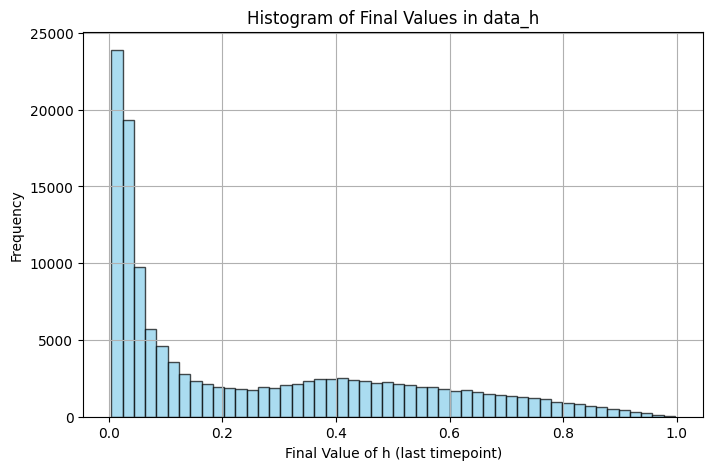

In [133]:
plt.figure(figsize=(8, 5))
plt.hist(data_h[:, -1], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('Final Value of h (last timepoint)')
plt.ylabel('Frequency')
plt.title('Histogram of Final Values in data_h')
plt.grid(True)
plt.show()

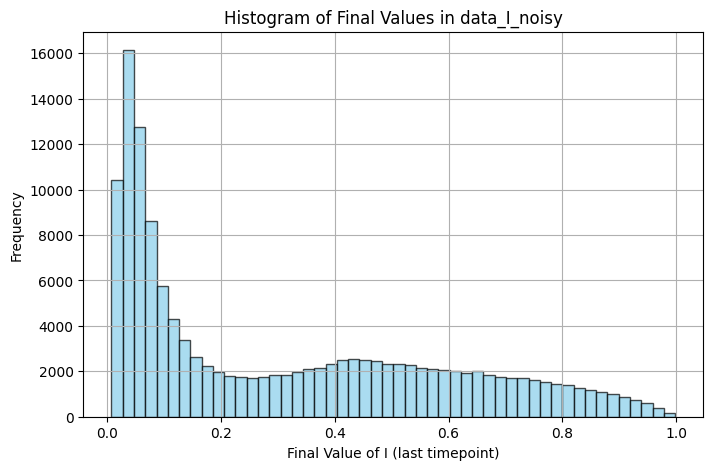

In [134]:
plt.figure(figsize=(8, 5))
# Flatten the last timepoint for all samples in both groups
final_values = data_I_noisy[:, -1].flatten()
plt.hist(final_values, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('Final Value of I (last timepoint)')
plt.ylabel('Frequency')
plt.title('Histogram of Final Values in data_I_noisy')
plt.grid(True)
plt.show()

In [135]:
min_value = np.min(data_I_clean)
min_index = np.unravel_index(np.argmin(data_I_clean), data_I_clean.shape)
print(f"Minimum value in data_I_clean: {min_value}")
print(f"Index of minimum value: {min_index}")

Minimum value in data_I_clean: 0.007573191437130101
Index of minimum value: (np.int64(101768), np.int64(600))


In [136]:
num_rows_greater_than_1 = np.sum(np.any(data_I_noisy <0., axis=1))
print(f"Number of rows in data_I_noisy with any value < 0: {num_rows_greater_than_1}")

Number of rows in data_I_noisy with any value < 0: 0


Parameters for n=96670:
J_e: 37.23414193955301
b_1: 1254.8448831290104
b_2: 1520.3075949302672
h_e: 0.0
f_0: 0.3334254329090758
P_c: 0.38670316264989596
phi: 0.5232104520319713
ts_halton: 1330.622298065051
h_0: 5.6207751418291775e-06
At t = 0, dh/dt: -91.21074987225316, dc/dt: 0.2599596557586352


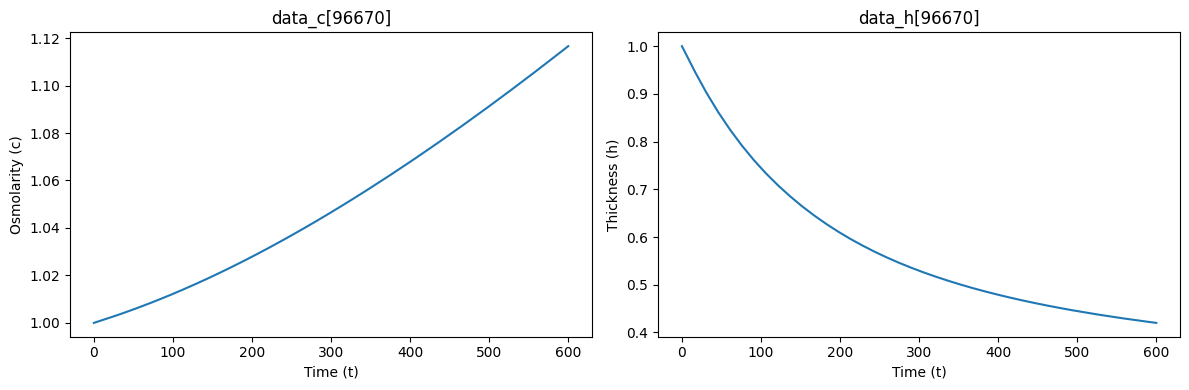

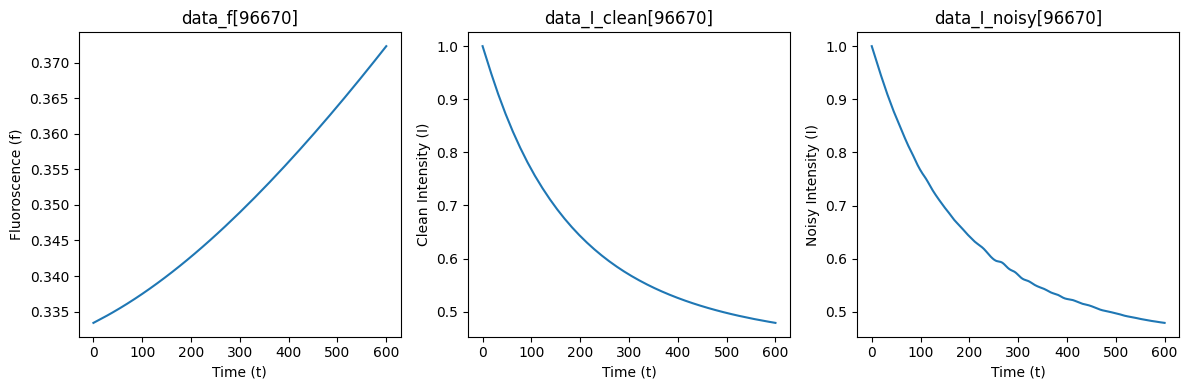

In [137]:
n = np.random.randint(0, data_h.shape[0])  # Randomly select an index for demonstration

print(f"Parameters for n={n}:")
J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts =data_p[n]
print(f"J_e: {J_e}")
print(f"b_1: {b_1}")
print(f"b_2: {b_2}")
print(f"h_e: {h_e}")
print(f"f_0: {f_0}")
print(f"P_c: {Pc}")
print(f"phi: {phi}")
print(f"ts_halton: {ts}")
print(f"h_0: {h0}")

dh_dt, dc_dt = differential_system(0, [1.0, 1.0], J_e_values[n], b_1_values[n], b_2_values[n], h_e_values[n], Pc_values[n])
print(f"At t = 0, dh/dt: {dh_dt}, dc/dt: {dc_dt}")

# Assuming n is the index and both data_c[n] and data_h[n] are 1D arrays
fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(data_c[n])
axs[0].set_title('data_c[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')

# Plot data_h[n]
axs[1].plot(data_h[n])
axs[1].set_title('data_h[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 3, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(data_f[n])
axs[0].set_title('data_f[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Fluoroscence (f)')

# Plot data_h[n]
axs[1].plot(data_I_clean[n])
axs[1].set_title('data_I_clean[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Clean Intensity (I)')

axs[2].plot(data_I_noisy[n])
axs[2].set_title('data_I_noisy[{}]'.format(n))
axs[2].set_xlabel('Time (t)')
axs[2].set_ylabel('Noisy Intensity (I)')

plt.tight_layout()
plt.show()

Parameters for n=80044:
J_e: 0.0009488745041770179
b_1: 665.7441152660859
b_2: 1671.1496765377658
h_e: 0.0
f_0: 0.33127192127220645
P_c: 0.491145146283032
phi: 0.5388599444777812
ts_halton: 1000.8160580817402
h_0: 5.7888954035327356e-06
At t = 0, dh/dt: -61.05254291387658, dc/dt: 4.23011649198974


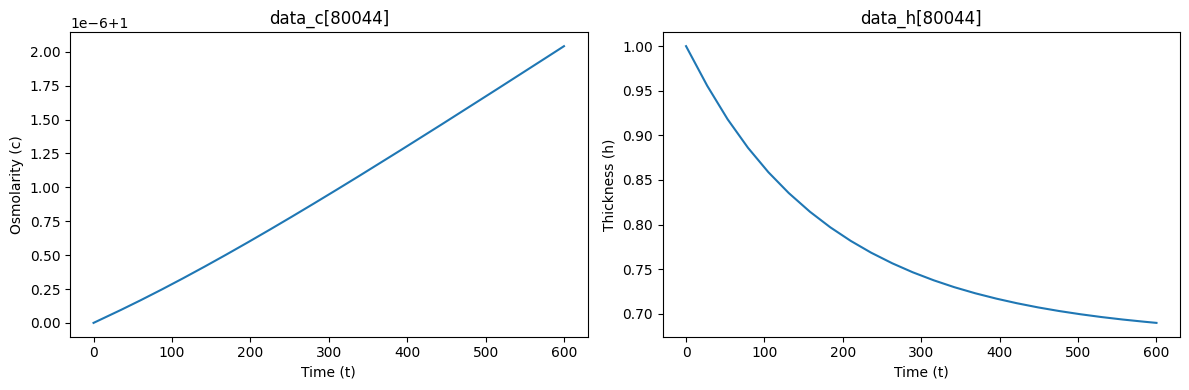

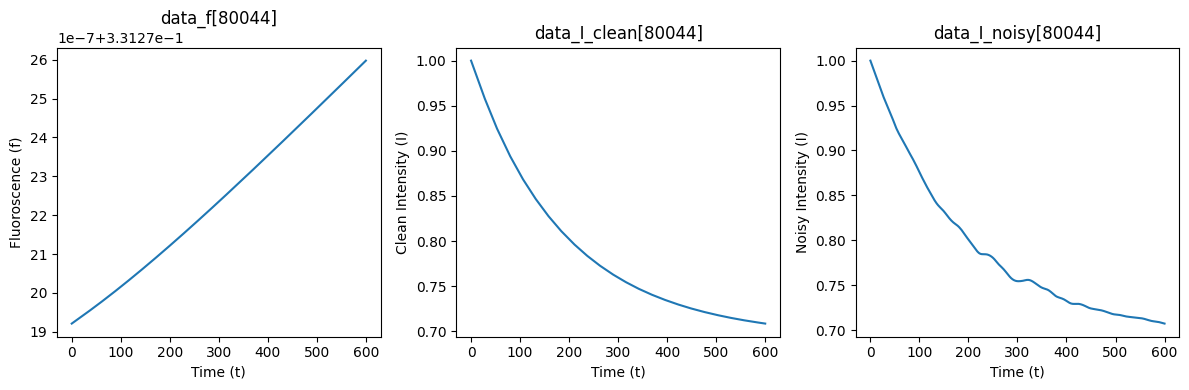

In [138]:
n = np.argmin(data_c[:,600])

print(f"Parameters for n={n}:")
J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts =data_p[n]
print(f"J_e: {J_e}")
print(f"b_1: {b_1}")
print(f"b_2: {b_2}")
print(f"h_e: {h_e}")
print(f"f_0: {f_0}")
print(f"P_c: {Pc}")
print(f"phi: {phi}")
print(f"ts_halton: {ts}")
print(f"h_0: {h0}")

dh_dt, dc_dt = differential_system(0, [1.0, 1.0], J_e_values[n], b_1_values[n], b_2_values[n], h_e_values[n], Pc_values[n])
print(f"At t = 0, dh/dt: {dh_dt}, dc/dt: {dc_dt}")

# Assuming n is the index and both data_c[n] and data_h[n] are 1D arrays
fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(data_c[n])
axs[0].set_title('data_c[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')

# Plot data_h[n]
axs[1].plot(data_h[n])
axs[1].set_title('data_h[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 3, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(data_f[n])
axs[0].set_title('data_f[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Fluoroscence (f)')

# Plot data_h[n]
axs[1].plot(data_I_clean[n])
axs[1].set_title('data_I_clean[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Clean Intensity (I)')

axs[2].plot(data_I_noisy[n])
axs[2].set_title('data_I_noisy[{}]'.format(n))
axs[2].set_xlabel('Time (t)')
axs[2].set_ylabel('Noisy Intensity (I)')

plt.tight_layout()
plt.show()

Parameters for n=31466:
J_e: 92.8424200266216
b_1: 2137.4594353784723
b_2: 153.65110218535796
h_e: 0.0
f_0: 0.1796067471977135
P_c: 0.13207466283795877
phi: 0.7310047301101967
ts_halton: 1095.290848500592
h_0: 7.853079386326686e-06
At t = 0, dh/dt: -90.72230888996964, dc/dt: 3.24248893090477


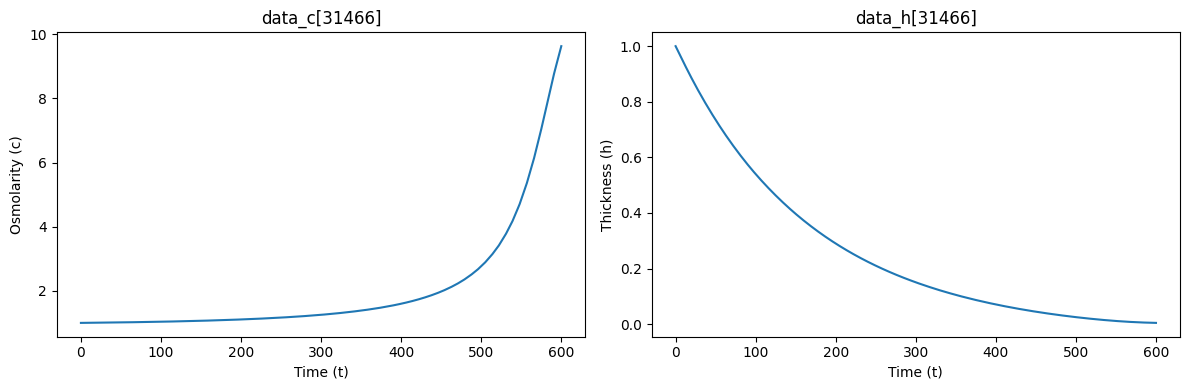

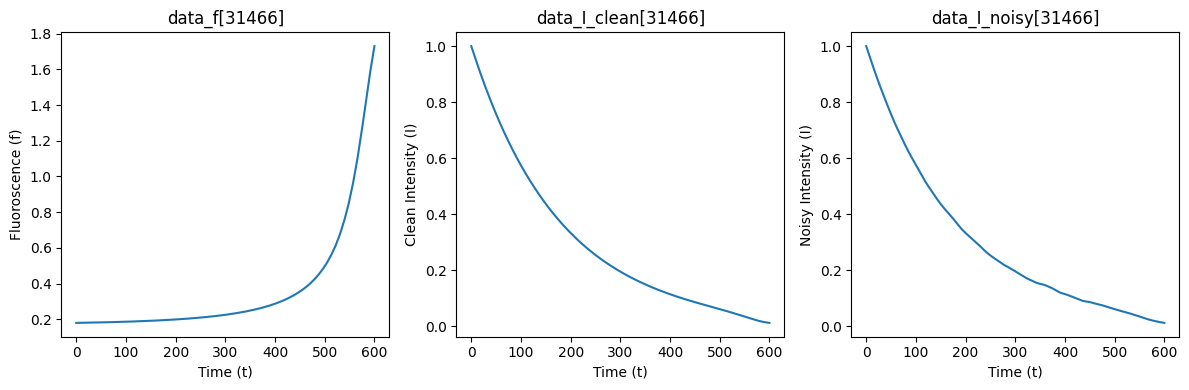

In [139]:
n = np.argmin(data_h[:,600])

print(f"Parameters for n={n}:")
J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts =data_p[n]
print(f"J_e: {J_e}")
print(f"b_1: {b_1}")
print(f"b_2: {b_2}")
print(f"h_e: {h_e}")
print(f"f_0: {f_0}")
print(f"P_c: {Pc}")
print(f"phi: {phi}")
print(f"ts_halton: {ts}")
print(f"h_0: {h0}")

dh_dt, dc_dt = differential_system(0, [1.0, 1.0], J_e_values[n], b_1_values[n], b_2_values[n], h_e_values[n], Pc_values[n])
print(f"At t = 0, dh/dt: {dh_dt}, dc/dt: {dc_dt}")

# Assuming n is the index and both data_c[n] and data_h[n] are 1D arrays
fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(data_c[n])
axs[0].set_title('data_c[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')

# Plot data_h[n]
axs[1].plot(data_h[n])
axs[1].set_title('data_h[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 3, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(data_f[n])
axs[0].set_title('data_f[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Fluoroscence (f)')

# Plot data_h[n]
axs[1].plot(data_I_clean[n])
axs[1].set_title('data_I_clean[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Clean Intensity (I)')

axs[2].plot(data_I_noisy[n])
axs[2].set_title('data_I_noisy[{}]'.format(n))
axs[2].set_xlabel('Time (t)')
axs[2].set_ylabel('Noisy Intensity (I)')

plt.tight_layout()
plt.show()

Parameters for n=101768:
J_e: 84.8030982717264
b_1: 2128.9883940306804
b_2: 127.42605016469
h_e: 0.0
f_0: 0.3143979355420276
P_c: 0.09171371540561499
phi: 0.7305959158894312
ts_halton: 1145.7385804378825
h_0: 7.848687553555033e-06
At t = 0, dh/dt: -19.910044209791273, dc/dt: 1.4342083415087288


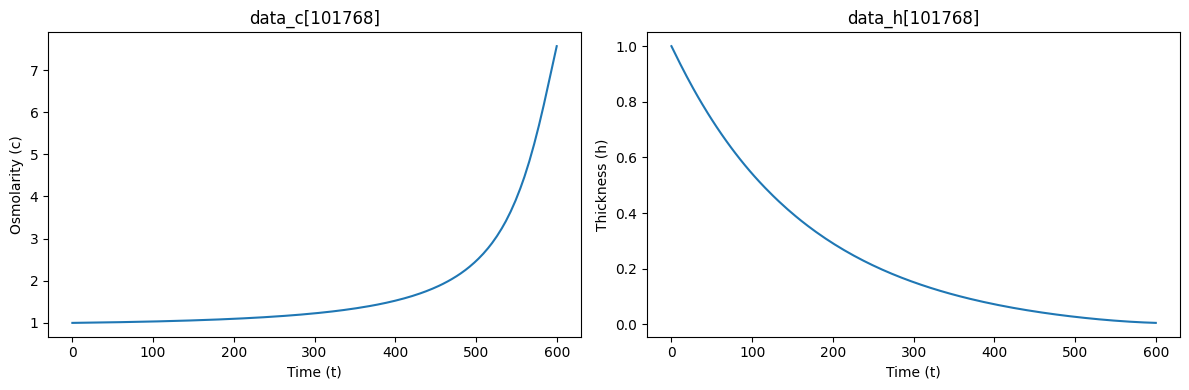

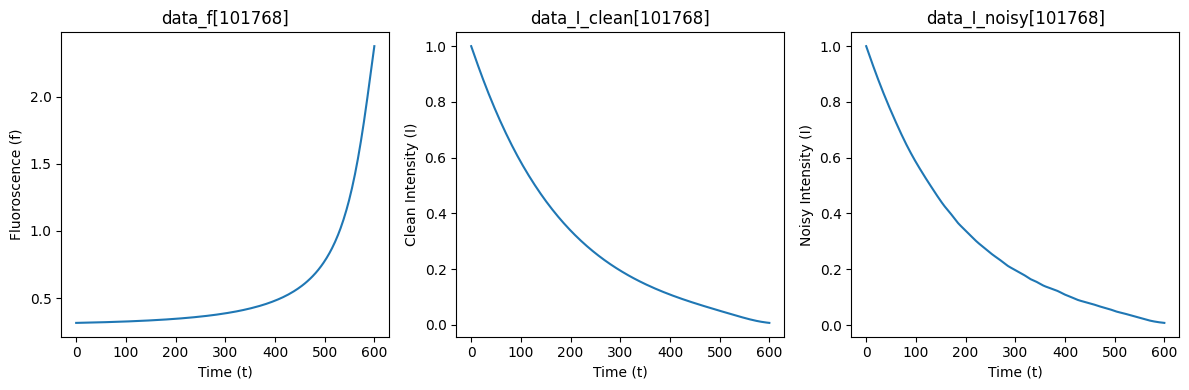

In [140]:
n = np.argmin(data_I_clean[:,600])

print(f"Parameters for n={n}:")
J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts =data_p[n]
print(f"J_e: {J_e}")
print(f"b_1: {b_1}")
print(f"b_2: {b_2}")
print(f"h_e: {h_e}")
print(f"f_0: {f_0}")
print(f"P_c: {Pc}")
print(f"phi: {phi}")
print(f"ts_halton: {ts}")
print(f"h_0: {h0}")

dh_dt, dc_dt = differential_system(0, [1.0, 1.0], J_e_values[n], b_1_values[n], b_2_values[n], h_e_values[n], Pc_values[n])
print(f"At t = 0, dh/dt: {dh_dt}, dc/dt: {dc_dt}")

# Assuming n is the index and both data_c[n] and data_h[n] are 1D arrays
fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(data_c[n])
axs[0].set_title('data_c[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')

# Plot data_h[n]
axs[1].plot(data_h[n])
axs[1].set_title('data_h[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 3, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(data_f[n])
axs[0].set_title('data_f[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Fluoroscence (f)')

# Plot data_h[n]
axs[1].plot(data_I_clean[n])
axs[1].set_title('data_I_clean[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Clean Intensity (I)')

axs[2].plot(data_I_noisy[n])
axs[2].set_title('data_I_noisy[{}]'.format(n))
axs[2].set_xlabel('Time (t)')
axs[2].set_ylabel('Noisy Intensity (I)')

plt.tight_layout()
plt.show()

Parameters for n=27250:
J_e: 0.6224887847800746
b_1: 6.953855556092562
b_2: 2648.4942918680986
h_e: 0.0
f_0: 0.251965892894451
P_c: 0.15398480114279453
phi: 0.5045983701559864
ts_halton: 1481.9118116054447
h_0: 5.420828205104312e-06
At t = 0, dh/dt: -19.116636684675345, dc/dt: 0.6999362919466421


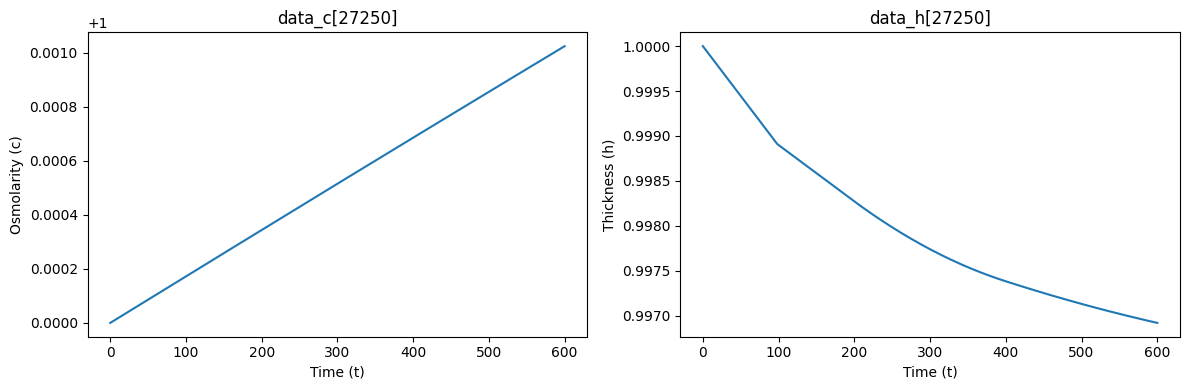

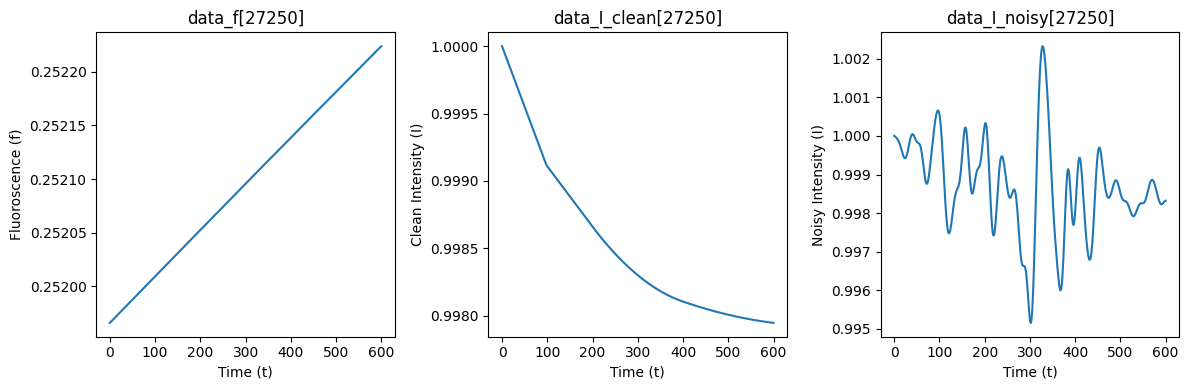

In [141]:
n = np.argmax(data_h[:,600])

print(f"Parameters for n={n}:")
J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts =data_p[n]
print(f"J_e: {J_e}")
print(f"b_1: {b_1}")
print(f"b_2: {b_2}")
print(f"h_e: {h_e}")
print(f"f_0: {f_0}")
print(f"P_c: {Pc}")
print(f"phi: {phi}")
print(f"ts_halton: {ts}")
print(f"h_0: {h0}")

dh_dt, dc_dt = differential_system(0, [1.0, 1.0], J_e_values[n], b_1_values[n], b_2_values[n], h_e_values[n], Pc_values[n])
print(f"At t = 0, dh/dt: {dh_dt}, dc/dt: {dc_dt}")

# Assuming n is the index and both data_c[n] and data_h[n] are 1D arrays
fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(data_c[n])
axs[0].set_title('data_c[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Osmolarity (c)')

# Plot data_h[n]
axs[1].plot(data_h[n])
axs[1].set_title('data_h[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Thickness (h)')

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 3, figsize=(12, 4))  # 1 row, 2 columns

# Plot data_c[n]
axs[0].plot(data_f[n])
axs[0].set_title('data_f[{}]'.format(n))
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('Fluoroscence (f)')

# Plot data_h[n]
axs[1].plot(data_I_clean[n])
axs[1].set_title('data_I_clean[{}]'.format(n))
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Clean Intensity (I)')

axs[2].plot(data_I_noisy[n])
axs[2].set_title('data_I_noisy[{}]'.format(n))
axs[2].set_xlabel('Time (t)')
axs[2].set_ylabel('Noisy Intensity (I)')

plt.tight_layout()
plt.show()

In [142]:
import pandas as pd

# Create a dictionary with the variables and their min/max values
data = {
    "Variable": ["h_0_values", "h_e_values", "J_e_values", "phi_values", "b_1_values", "b_2_values", "Pc_values"],
    "Min Value": [
        h_0_values.min(),
        h_e_values.min(),
        J_e_values.min(),
        phi_values.min(),
        b_1_values.min(),
        b_2_values.min(),
        Pc_values.min()
    ],
    "Max Value": [
        h_0_values.max(),
        h_e_values.max(),
        J_e_values.max(),
        phi_values.max(),
        b_1_values.max(),
        b_2_values.max(),
        Pc_values.max()
    ]
}

# Create a DataFrame for better visualization
table = pd.DataFrame(data)

# Display the table
print(table)

     Variable  Min Value   Max Value
0  h_0_values   0.000002    0.000008
1  h_e_values   0.062599    0.498555
2  J_e_values   0.000006   19.922588
3  phi_values   0.186171    0.744680
4  b_1_values -11.912739  119.907933
5  b_2_values   0.000018  119.654817
6   Pc_values   0.081917    1.956037


In [143]:
max_values_data_c = np.max(data_c, axis=1)
print(max_values_data_c.min(), max_values_data_c.max())

min_values_data_c = np.min(data_c, axis=1)
print(min_values_data_c.min(), min_values_data_c.max())

max_values_data_h = np.max(data_h, axis=1)
print(max_values_data_h.min(), max_values_data_h.max())

min_values_data_h = np.min(data_h, axis=1)
print(min_values_data_h.min(), min_values_data_h.max())

max_values_data_f = np.max(data_f, axis=1)
print(max_values_data_f.min(), max_values_data_f.max())

min_values_data_f = np.min(data_f, axis=1)
print(min_values_data_f.min(), min_values_data_f.max())

max_values_data_I = np.max(data_I_noisy, axis=1)
print(max_values_data_I.min(), max_values_data_I.max())

min_values_data_I = np.min(data_I_noisy, axis=1)
print(min_values_data_I.min(), min_values_data_I.max())

1.0000020418258488 11.194324550830073
0.9999999999999997 1.0000000000000002
0.9999999999999999 1.0
0.004518142234032874 0.9969195223382046
0.15115579715438535 4.026078522755935
0.1509446702567539 0.3773583899559854
0.9995040378554825 1.0039532146647696
0.007362798313364705 0.9960078419025055
